# 01 — Signal processing baseline

**Dataset:** `aim_2023`

**Question:** Does telemetry contain reviewable recurring periods?

Source Time field is blank. Adapter generates elapsed_s = sample_index / 20 in memory after metadata and row-count validation. Raw CSV stays unchanged. Inertial channels drive recurrence analysis. Wheel-speed channels are constant zero. VerticalAcc carries a large offset despite declared g units. Recurrence candidates remain unverified.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.data import load_recording, select_informative_channels
from lap_estimation.integration import benchmark_interpolation, build_integrated_features
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
overview = pd.Series(
    {
        "recordings": len(manifest),
        "source_paths": int(manifest["alias_count"].sum()),
        "duration_min": manifest["duration_s"].sum() / 60.0,
        "native_sample_rate_hz": dataset.native_sample_rate_hz,
        "control_candidates": int(manifest["control_candidate"].sum()),
        "clock_provenance": dataset.clock_provenance,
    },
    name="value",
)
overview.to_frame()

,value
recordings,18
source_paths,18
duration_min,33.701667
native_sample_rate_hz,20.0
control_candidates,7
clock_provenance,inferred_uniform_from_metadata


In [3]:
result = run_experiment("01_signal_processing", ROOT, dataset_key=DATASET_KEY)
profile = pd.read_csv(result.output_dir / "data_profile.csv")
coverage = pd.read_csv(result.output_dir / "sensor_coverage.csv")
candidates = pd.read_csv(result.output_dir / "periodicity_candidates.csv")
smoothing = pd.read_csv(result.output_dir / "smoothing_sensitivity.csv")
display(result.metrics)
display(result.predictions.sort_values("score", ascending=False))
display(profile.sort_values("duration_s", ascending=False))

,task,split,metric,value,sample_count,reference_source
0,recurrence,all,non_control_recording_coverage,0.727273,11,none
1,recurrence,all,non_control_review_candidate_rate,0.125000,8,unverified_threshold
2,recurrence,all,control_candidate_detection_rate,0.500000,2,training_low_dynamics_quantile
3,data_quality,all,duplicate_alias_count,0.000000,18,sha256


,recording_id,segment_id,start_s,end_s,prediction_kind,score,predicted_period_s,label_status
0,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,period_candidate_1,0.0,175.95,recurrence_period,0.253938,27.45,provisional_unverified
1,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,period_candidate_1,0.0,228.95,recurrence_period,0.250696,45.50,provisional_unverified
2,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,period_candidate_1,0.0,107.95,recurrence_period,0.232961,45.15,provisional_unverified
3,4975a35d789765b9299480af66d6a5af5166fef074cef8...,period_candidate_1,0.0,210.95,recurrence_period,0.228681,21.00,provisional_unverified
4,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,period_candidate_1,0.0,217.95,recurrence_period,0.204464,20.10,provisional_unverified
5,b185f43818b8ff3aba325752922bbbf37fd094f1e28288...,period_candidate_1,0.0,123.95,recurrence_period,0.196036,46.00,provisional_unverified
6,bace0e92b25324e8afbd0e5f6698b01a921780a2385e02...,period_candidate_1,0.0,241.95,recurrence_period,0.189051,15.05,provisional_unverified
7,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,period_candidate_1,0.0,89.95,recurrence_period,0.176924,39.95,provisional_unverified
8,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,period_candidate_1,0.0,456.95,recurrence_period,0.118885,59.15,provisional_unverified
9,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,period_candidate_1,0.0,33.95,recurrence_period,0.002243,15.25,provisional_unverified


,recording_id,alias_count,driver_labels,driver_ambiguous,row_count,duration_s,declared_duration_s,sampled_elapsed_span_s,median_interval_s,max_gap_s,dynamic_numeric_count,max_abs_rpm,motion_variation_score,motion_status,motion_status_source,control_candidate,clock_provenance,vertical_accel_offset_flag,split
0,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,1,[],False,9140,456.95,457.0,456.95,0.05,0.05,31,12651.2881,10.185510,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
1,bace0e92b25324e8afbd0e5f6698b01a921780a2385e02...,1,[],False,4840,241.95,242.0,241.95,0.05,0.05,32,12223.2646,10.247195,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,test
2,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,1,[],False,4580,228.95,229.0,228.95,0.05,0.05,31,12546.4854,10.578880,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
3,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,1,[],False,4360,217.95,218.0,217.95,0.05,0.05,32,14706.2178,12.692235,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
4,4975a35d789765b9299480af66d6a5af5166fef074cef8...,1,[],False,4220,210.95,211.0,210.95,0.05,0.05,32,12737.6172,11.872775,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
5,dc8bf44eb4cc0becf1c5ebe252a515c98193744c203149...,1,[],False,3520,175.95,176.0,175.95,0.05,0.05,31,3303.6799,0.555565,low_dynamics_candidate,training_low_dynamics_quantile,True,inferred_uniform_from_metadata,True,test
6,b185f43818b8ff3aba325752922bbbf37fd094f1e28288...,1,[],False,2480,123.95,124.0,123.95,0.05,0.05,31,13173.3008,15.008220,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,validation
7,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,1,[],False,2160,107.95,108.0,107.95,0.05,0.05,31,14395.8545,16.275785,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
8,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,1,[],False,1800,89.95,90.0,89.95,0.05,0.05,31,6860.6284,1.950930,dynamic_candidate,training_low_dynamics_quantile,False,inferred_uniform_from_metadata,True,train
9,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,1,[],False,680,33.95,34.0,33.95,0.05,0.05,32,6421.2256,1.236015,low_dynamics_candidate,training_low_dynamics_quantile,True,inferred_uniform_from_metadata,True,train


## Recording inventory and sensor availability

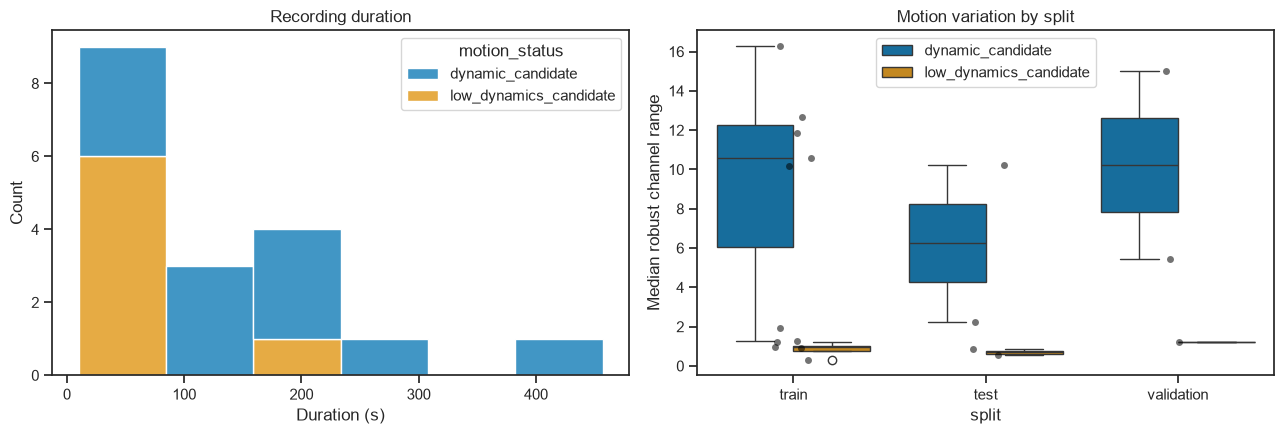

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=profile, x="duration_s", hue="motion_status", multiple="stack", ax=axes[0])
axes[0].set(title="Recording duration", xlabel="Duration (s)")
sns.boxplot(data=profile, x="split", y="motion_variation_score", hue="motion_status", ax=axes[1])
sns.stripplot(data=profile, x="split", y="motion_variation_score", color="black", alpha=0.55, ax=axes[1])
axes[1].set(title="Motion variation by split", ylabel="Median robust channel range")
fig.tight_layout()

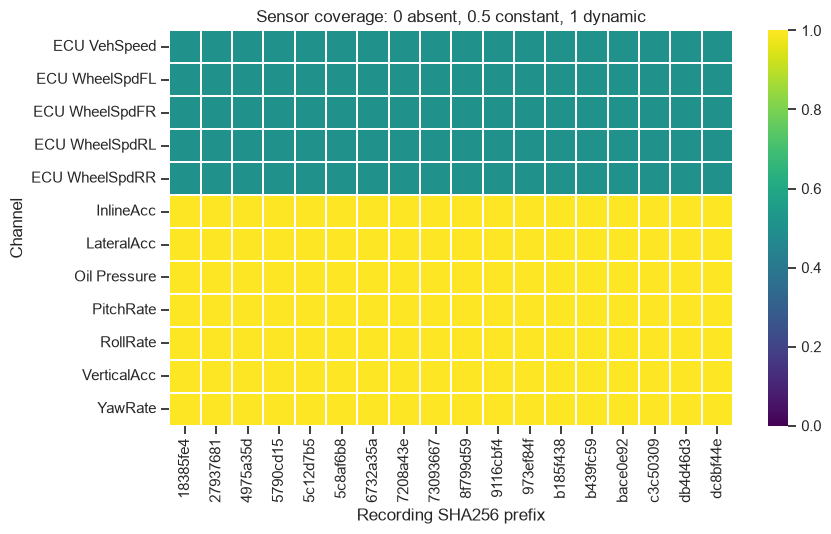

In [5]:
coverage_matrix = coverage.assign(recording=coverage["recording_id"].str[:8], available=coverage["state"].map({"absent": 0, "constant": 0.5, "dynamic": 1.0})).pivot(index="channel", columns="recording", values="available")
fig, ax = plt.subplots(figsize=(max(9, coverage_matrix.shape[1] * 0.45), 5.5))
sns.heatmap(coverage_matrix, cmap="viridis", vmin=0, vmax=1, linewidths=0.2, ax=ax)
ax.set(title="Sensor coverage: 0 absent, 0.5 constant, 1 dynamic", xlabel="Recording SHA256 prefix", ylabel="Channel")
fig.tight_layout()

## Representative native sensor traces

Text(0.5, 1.01, 'aim_2023: longest non-control recordings')

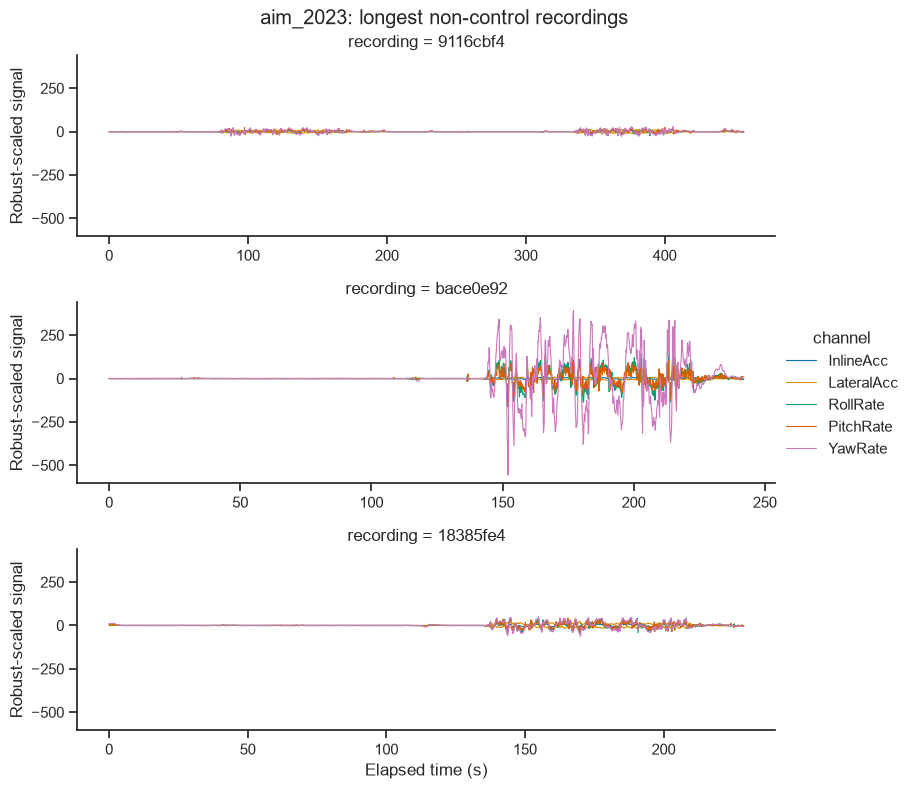

In [6]:
trace_rows = []
selected_records = manifest.loc[~manifest["control_candidate"]].nlargest(3, "duration_s")
for record in selected_records.itertuples(index=False):
    frame = load_recording(record.primary_path, dataset)
    channels = select_informative_channels(frame, dataset.analysis_channels)
    step = max(1, len(frame) // 1500)
    sampled = frame.iloc[::step]
    for channel in channels:
        values = pd.to_numeric(sampled[channel], errors="coerce")
        scale = values.quantile(0.75) - values.quantile(0.25)
        scaled = (values - values.median()) / (scale if scale > 1e-12 else 1.0)
        trace_rows.append(pd.DataFrame({"elapsed_s": sampled["elapsed_s"], "scaled_value": scaled, "channel": channel, "recording": record.recording_id[:8]}))
trace_data = pd.concat(trace_rows, ignore_index=True)
grid = sns.relplot(data=trace_data, x="elapsed_s", y="scaled_value", hue="channel", col="recording", col_wrap=1, kind="line", height=2.6, aspect=3.1, linewidth=0.8, facet_kws={"sharex": False})
grid.set_axis_labels("Elapsed time (s)", "Robust-scaled signal")
grid.figure.suptitle(f"{DATASET_KEY}: longest non-control recordings", y=1.01)

## Recurrence candidates and smoothing sensitivity

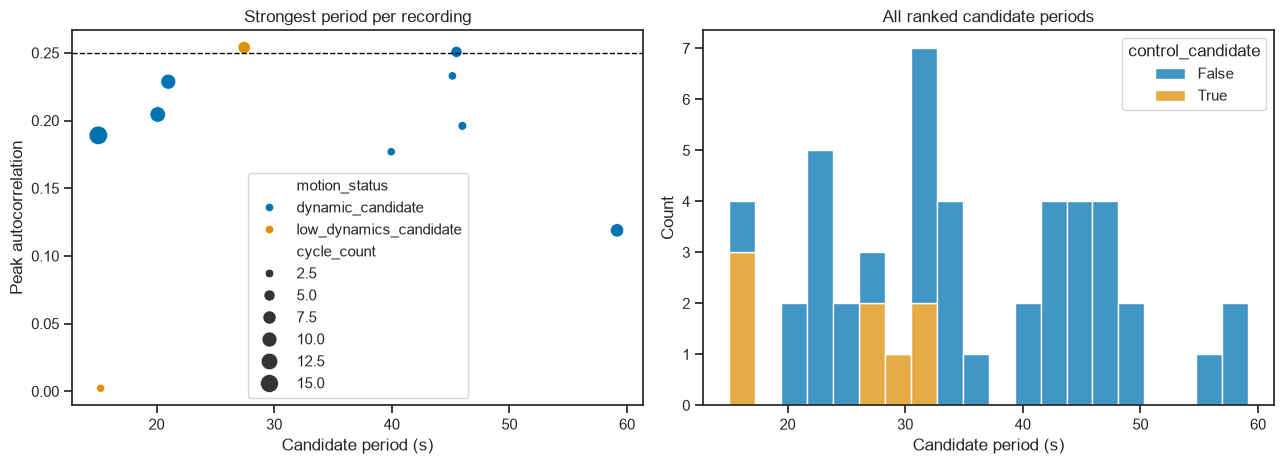

In [7]:
top = candidates.loc[candidates["rank"] == 1].merge(manifest[["recording_id", "motion_status"]], on="recording_id", how="left")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(data=top, x="lag_s", y="correlation", hue="motion_status", size="cycle_count", sizes=(35, 180), ax=axes[0])
axes[0].axhline(0.25, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Strongest period per recording", xlabel="Candidate period (s)", ylabel="Peak autocorrelation")
sns.histplot(data=candidates, x="lag_s", hue="control_candidate", multiple="stack", bins=20, ax=axes[1])
axes[1].set(title="All ranked candidate periods", xlabel="Candidate period (s)")
fig.tight_layout()

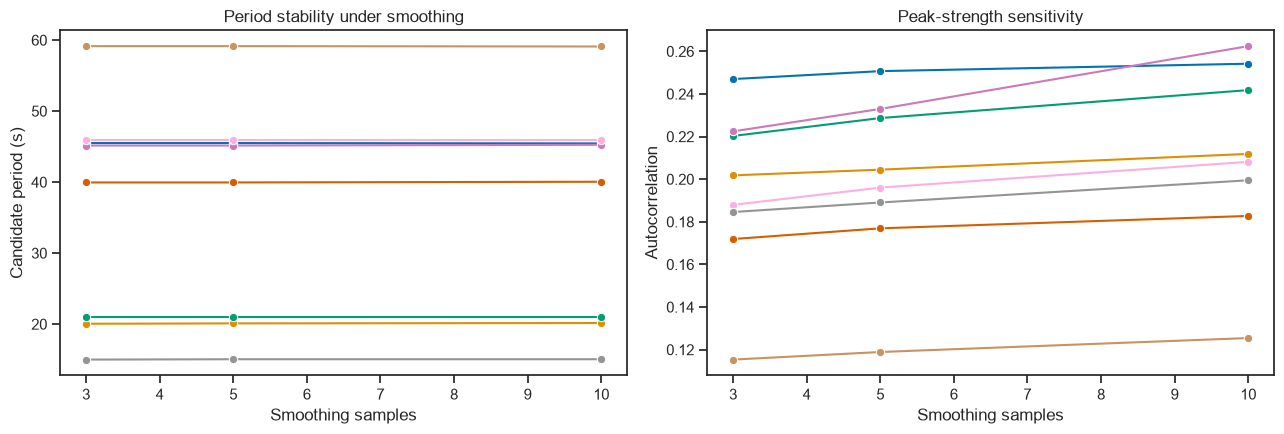

In [8]:
if len(smoothing):
    smoothing_plot = smoothing.assign(recording=smoothing["recording_id"].str[:8])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.lineplot(data=smoothing_plot, x="smooth_samples", y="lag_s", hue="recording", marker="o", legend=False, ax=axes[0])
    axes[0].set(title="Period stability under smoothing", xlabel="Smoothing samples", ylabel="Candidate period (s)")
    sns.lineplot(data=smoothing_plot, x="smooth_samples", y="correlation", hue="recording", marker="o", legend=False, ax=axes[1])
    axes[1].set(title="Peak-strength sensitivity", xlabel="Smoothing samples", ylabel="Autocorrelation")
    fig.tight_layout()

## Controlled interpolation sensitivity

Observed timestamps are already regular. Samples are deliberately hidden, then reconstructed from elapsed time. This tests gap sensitivity; it does not recover new timing information.

Text(0.5, 1.03, 'aim_2023: interpolation sensitivity')

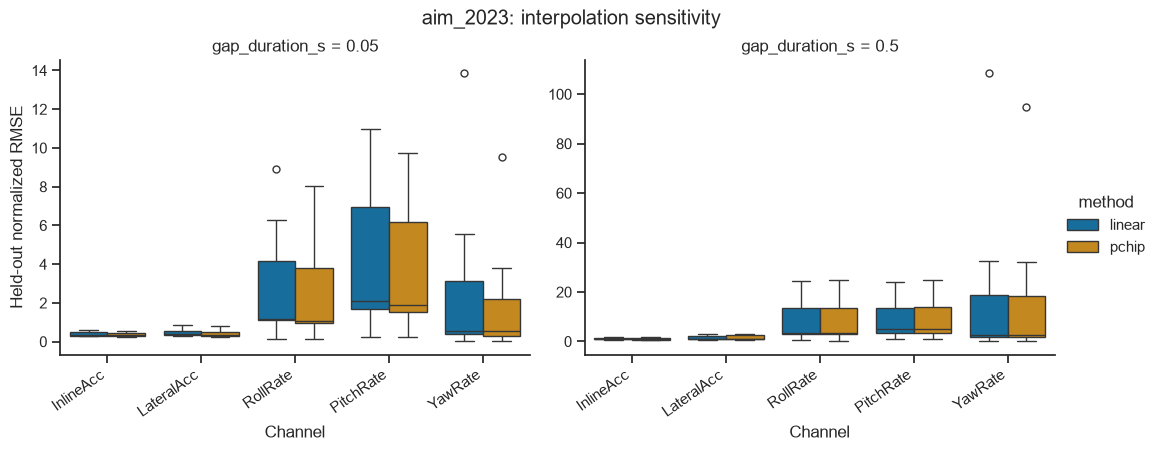

In [9]:
benchmark_rows = []
benchmark_records = pd.concat([manifest.nlargest(6, "duration_s"), manifest.loc[manifest["control_candidate"]].nlargest(2, "duration_s")]).drop_duplicates("recording_id")
long_gap_samples = max(2, round(dataset.native_sample_rate_hz * 0.5))
for record in benchmark_records.itertuples(index=False):
    frame = load_recording(record.primary_path, dataset)
    channels = select_informative_channels(frame, dataset.analysis_channels)
    benchmark = benchmark_interpolation(frame, channels, gap_samples=(1, long_gap_samples))
    benchmark["recording_id"] = record.recording_id
    benchmark["motion_status"] = record.motion_status
    benchmark_rows.append(benchmark)
interpolation = pd.concat(benchmark_rows, ignore_index=True)
interpolation["gap_duration_s"] = interpolation["gap_samples"] / dataset.native_sample_rate_hz
interpolation.to_csv(result.output_dir / "interpolation_benchmark.csv", index=False)
grid = sns.catplot(data=interpolation, x="channel", y="normalized_rmse", hue="method", col="gap_duration_s", kind="box", sharey=False, height=4.0, aspect=1.35)
grid.set_xticklabels(rotation=35, ha="right")
grid.set_axis_labels("Channel", "Held-out normalized RMSE")
grid.figure.suptitle(f"{DATASET_KEY}: interpolation sensitivity", y=1.03)

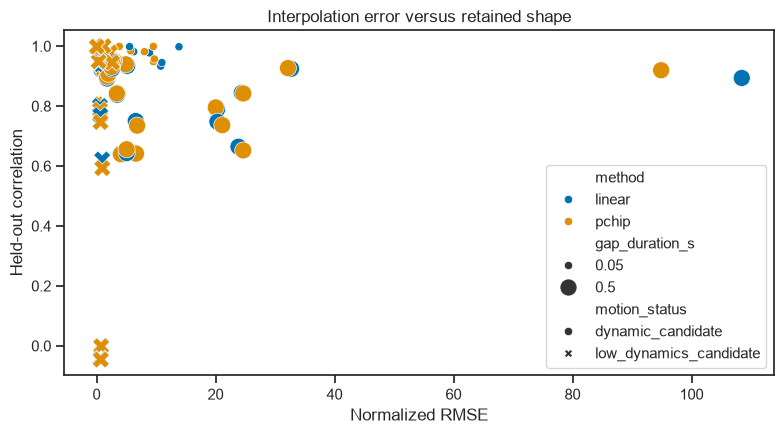

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=interpolation, x="normalized_rmse", y="correlation", hue="method", style="motion_status", size="gap_duration_s", sizes=(35, 150), ax=ax)
ax.set(title="Interpolation error versus retained shape", xlabel="Normalized RMSE", ylabel="Held-out correlation")
fig.tight_layout()

## Physically interpretable cumulative proxies

Text(0.5, 1.02, 'aim_2023: integrated sensor proxies, recording 9116cbf4')

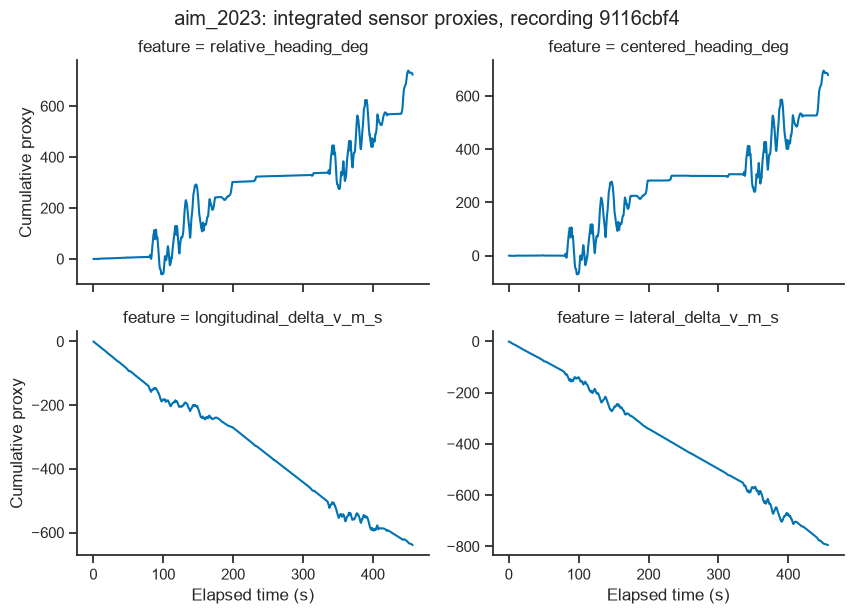

In [11]:
example = manifest.loc[~manifest["control_candidate"]].nlargest(1, "duration_s").iloc[0]
example_frame = load_recording(example["primary_path"], dataset)
integrated = build_integrated_features(example_frame, DATASET_KEY)
integrated.to_csv(result.output_dir / "integrated_features_example.csv", index=False)
integrated_long = integrated.melt(id_vars="elapsed_s", var_name="feature", value_name="value")
grid = sns.relplot(data=integrated_long, x="elapsed_s", y="value", col="feature", col_wrap=2, kind="line", height=3.0, aspect=1.45, facet_kws={"sharey": False})
grid.set_axis_labels("Elapsed time (s)", "Cumulative proxy")
grid.figure.suptitle(f"{DATASET_KEY}: integrated sensor proxies, recording {example['recording_id'][:8]}", y=1.02)

In [12]:
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
run_manifest["data_provenance"]

{'dataset_key': 'aim_2023',
 'native_sample_rate_hz': 20.0,
 'clock_provenance': 'inferred_uniform_from_metadata',
 'selected_channels': ['InlineAcc',
  'LateralAcc',
  'RollRate',
  'PitchRate',
  'YawRate'],
 'semantic_mapping': {'InlineAcc': 'longitudinal_accel_g',
  'LateralAcc': 'lateral_accel_g',
  'VerticalAcc': 'vertical_accel_g',
  'RollRate': 'roll_rate_deg_s',
  'PitchRate': 'pitch_rate_deg_s',
  'YawRate': 'yaw_rate_deg_s',
  'ECU RPM': 'engine_rpm',
  'ECU ThrottlePos': 'throttle_pct',
  'Oil Pressure': 'oil_pressure_bar',
  'Rear Brake': 'rear_brake_pressure_bar'},
 'semantic_mapping_version': '1.0',
 'motion_policy': 'training_low_dynamics_quantile'}

## Interpretation boundary

Positive recurrence means measured behavior repeats. It does not prove laps, locate a start line, identify a driver, or establish accuracy. Integrated RPM gives shaft revolutions, not distance. Electrical integration is an energy proxy. Yaw and acceleration integrals drift and provide only bounded relative-motion proxies.